In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
import warnings
warnings.filterwarnings("ignore")

# Google Drive 연결, 작업공간 설정
from google.colab import drive
import os
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/deeplearning_study')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [26]:
# data loading (자주 등장하는 단어 1만개만 분석에 사용함)
from tensorflow.keras.datasets import imdb
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=10000)

print("Train size :", len(X_train))
print("Test size :", len(X_test))

Train size : 25000
Test size : 25000


---
### 데이터 확인
---

In [27]:
########################################################################
# 참고. 텐서플로 내장 IMDB는 이미 숫자 인코딩 되어 있음
# 텍스트 확인을 위해서는 word_index를 불러와 매칭시켜야 함
########################################################################

word_index = imdb.get_word_index()

reverse_word_index = {value+3: key for key, value in word_index.items()}
reverse_word_index[0] = "<PAD>"
reverse_word_index[1] = "<START>"
reverse_word_index[2] = "<UNK>"
reverse_word_index[3] = "<UNUSED>"

# 첫번째, 두번째 text와 감성평가 결과(긍정 1, 부정 0) 확인
review1 = " ".join([reverse_word_index.get(i, "?") for i in X_train[0]])
sentiment1 = y_train[0]
print('리뷰1', review1)
print('평가1', sentiment1)

review2 = " ".join([reverse_word_index.get(i, "?") for i in X_train[1]])
sentiment2 = y_train[1]
print('리뷰2', review2)
print('평가2', sentiment2)

리뷰1 <START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for <UNK> and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also <UNK> to the two little boy's that played the <UNK> of norman and paul they were just brilliant children are often left out of the <UNK> list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for

평균리뷰길이: 238.71364
최소리뷰길이: 11
최대리뷰길이: 2494


<Axes: ylabel='Count'>

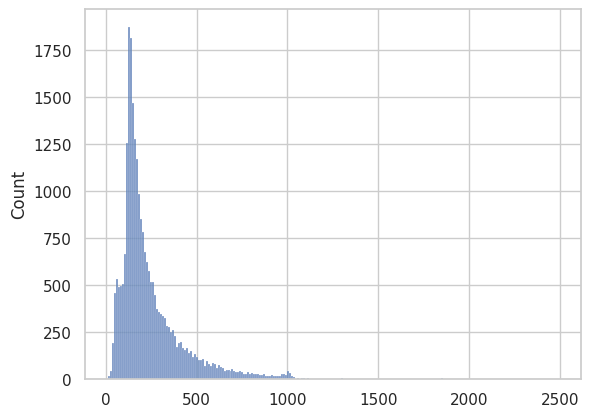

In [28]:
# 리뷰(텍스트) 길이
review_length = np.array([len(x) for x in X_train])
print('평균리뷰길이:', np.mean(review_length))
print('최소리뷰길이:', np.min(review_length))
print('최대리뷰길이:', np.max(review_length))

sns.histplot(review_length)

---
#### 데이터 전처리
---

In [29]:
########################################################################
# padding : 리뷰 건마다 텍스트 길이가 다름 -> 300을 기준으로 일치시킨다.
########################################################################
from tensorflow.keras.preprocessing.sequence import pad_sequences

train_seq = pad_sequences(X_train, maxlen=300)
test_seq = pad_sequences(X_test, maxlen=300)

print(train_seq.shape, test_seq.shape)

(25000, 300) (25000, 300)


In [30]:
########################################################################
# RNN model
# 원핫코딩은 비효율적 -> Embedding을 사용
########################################################################
from tensorflow import keras
model = keras.Sequential()
# Embedding 추가
model.add(keras.layers.Embedding(input_dim=10000, output_dim=32, input_length=300))
# RNN
model.add(keras.layers.SimpleRNN(8))
# 출력층
model.add(keras.layers.Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_4 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [31]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# compile
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    'best_imdb_model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# train
history = model.fit(
    train_seq,
    y_train,
    epochs=100,
    batch_size=64,
    validation_data=(test_seq, y_test),
    callbacks=[early_stop, checkpoint]
)

Epoch 1/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6142 - loss: 0.6341
Epoch 1: val_loss improved from None to 0.43646, saving model to best_imdb_model.keras

Epoch 1: finished saving model to best_imdb_model.keras
391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 30ms/step - accuracy: 0.7024 - loss: 0.5594 - val_accuracy: 0.8121 - val_loss: 0.4365
Epoch 2/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7945 - loss: 0.4506
Epoch 2: val_loss improved from 0.43646 to 0.43467, saving model to best_imdb_model.keras

Epoch 2: finished saving model to best_imdb_model.keras
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.7908 - loss: 0.4574 - val_accuracy: 0.8029 - val_loss: 0.4347
Epoch 3/100
389/391 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8676 - loss: 0.3269
Epoch 3: val_loss did not improve from 0.43467
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.8538 - loss: 0.3481 - val_accuracy: 0.7721 - val_loss: 0.4931
Epoch 4/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 

,accuracy,loss,val_accuracy,val_loss
2,0.85384,0.348107,0.77212,0.493105
3,0.89616,0.267303,0.81520,0.446743
4,0.92832,0.195446,0.81292,0.484749
5,0.95788,0.131095,0.79104,0.602692
6,0.97104,0.093663,0.80232,0.569861


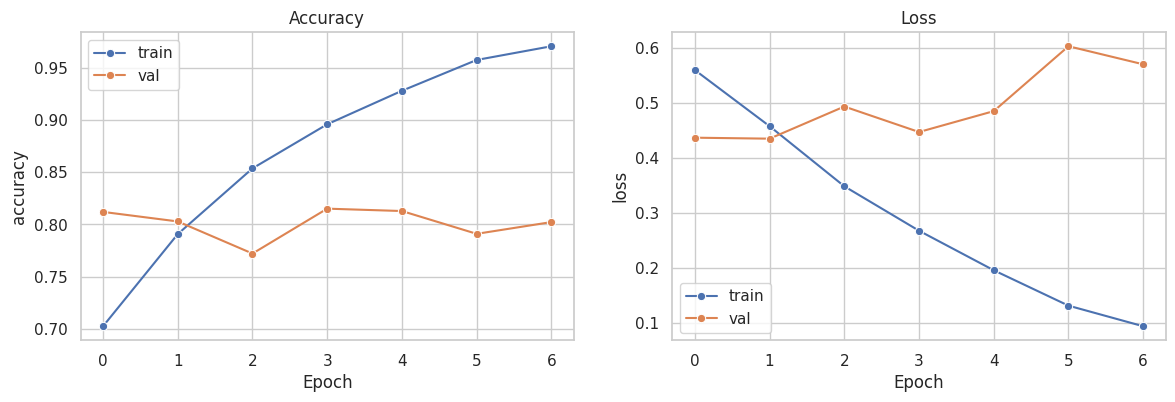

In [32]:
# visuzlaize
df_history = pd.DataFrame(history.history)
display(df_history.tail())

fig, axes = plt.subplots(1,2, figsize=(14,4))

sns.lineplot(data=df_history, x=df_history.index, y='accuracy', marker='o', label='train', ax=axes[0])
sns.lineplot(data=df_history, x=df_history.index, y='val_accuracy', marker='o', label='val', ax=axes[0])
axes[0].set_title('Accuracy')
axes[0].set_xlabel("Epoch")
axes[0].legend()

sns.lineplot(data=df_history, x=df_history.index, y='loss', marker='o', label='train', ax=axes[1])
sns.lineplot(data=df_history, x=df_history.index, y='val_loss', marker='o', label='val', ax=axes[1])
axes[1].set_title('Loss')
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.show()

In [40]:
# best model loading, test
best_model = keras.models.load_model('best_imdb_model.keras')
test_loss, test_acc = best_model.evaluate(test_seq, y_test)

print("Test accuracy:", test_acc)
print("Test loss:", test_loss)

782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8029 - loss: 0.4347
Test accuracy: 0.8029199838638306
Test loss: 0.4346714913845062
